In [1]:
import struct
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

In [2]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
class MNISTDataset(Dataset):

    def __init__(self, image_file, label_file):

        with open(label_file, 'rb') as lb:
            magic, num = struct.unpack(">II", lb.read(8))
            self.labels = np.fromfile(lb, dtype=np.uint8)

        with open(image_file, 'rb') as img:
            magic, num, rows, cols = struct.unpack(">IIII", img.read(16))
            self.images = np.fromfile(img, dtype=np.uint8)
            self.images = self.images.reshape(num, rows, cols)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        image = self.images[idx] / 255.0
        image = torch.tensor(image, dtype=torch.float32)

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return image, label

In [4]:
train_dataset = MNISTDataset(
    r"D:\dl_projects\handwritten_digit_recognition\model\datasets\train-images.idx3-ubyte",
    r"D:\dl_projects\handwritten_digit_recognition\model\datasets\train-labels.idx1-ubyte"
)

test_dataset = MNISTDataset(
    r"D:\dl_projects\handwritten_digit_recognition\model\datasets\t10k-images.idx3-ubyte",
    r"D:\dl_projects\handwritten_digit_recognition\model\datasets\t10k-labels.idx1-ubyte"
)

print("Training Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))

Training Samples: 60000
Testing Samples: 10000


In [5]:
g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    generator=g
)

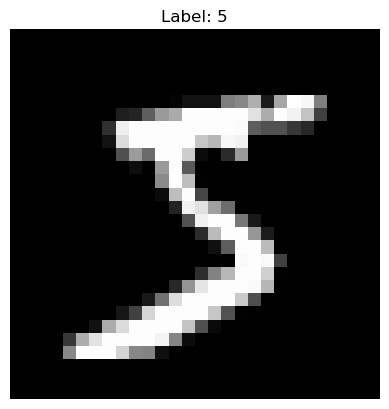

In [6]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [7]:
class DigitANN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = DigitANN().to(device)

print(model)

DigitANN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.002
)

In [10]:
epochs = 15

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}"
    )

Epoch 1/15 | Loss: 0.2517
Epoch 2/15 | Loss: 0.1343
Epoch 3/15 | Loss: 0.1033
Epoch 4/15 | Loss: 0.0928
Epoch 5/15 | Loss: 0.0798
Epoch 6/15 | Loss: 0.0729
Epoch 7/15 | Loss: 0.0634
Epoch 8/15 | Loss: 0.0599
Epoch 9/15 | Loss: 0.0545
Epoch 10/15 | Loss: 0.0499
Epoch 11/15 | Loss: 0.0465
Epoch 12/15 | Loss: 0.0438
Epoch 13/15 | Loss: 0.0410
Epoch 14/15 | Loss: 0.0378
Epoch 15/15 | Loss: 0.0375


In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.43%


In [12]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

train_acc = 100 * correct / total

print(f"Training Accuracy: {train_acc:.2f}%")

Training Accuracy: 99.80%


In [13]:
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [14]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[ 967    1    2    1    0    1    6    1    1    0]
 [   0 1128    3    0    0    0    2    1    1    0]
 [   0    0 1015    0    1    0    1   14    1    0]
 [   1    0    4  994    0    1    0    6    4    0]
 [   0    0    2    0  961    0    4    3    0   12]
 [   2    0    0    9    1  873    3    2    1    1]
 [   2    3    1    0    2    6  943    0    1    0]
 [   1    3    4    1    0    0    0 1014    2    3]
 [   5    1    1    2    1    1    1    3  958    1]
 [   1    2    0    3    5    0    0    3    5  990]]


In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

